In [1]:
import numpy as np
import imageio.v2 as io
import os
import pandas as pd
import matplotlib.pyplot as plt

# Data loading

In [2]:
# We will use a smaller version of the BAGLS dataset with 224x224 pixel images
# Original BAGLS dataset: bagls.org

data_path = 'C:/Data/Datasets/BAGLS_4096/'
file_names = os.listdir(data_path)

images = [data_path + x for x in file_names if not x.endswith('seg.png')]
masks = [x.split('.')[0]+'_seg.png' for x in images]

print(images[0])
print(masks[0])

C:/Data/Datasets/BAGLS_4096/10004.png
C:/Data/Datasets/BAGLS_4096/10004_seg.png


In [3]:
from sklearn.model_selection import train_test_split

# Split data into training and test dataset
train_im, test_im, train_masks, test_masks = train_test_split(images, masks, test_size=0.25, random_state=42)

print(len(train_im), len(test_im))

3072 1024


In [4]:
def load_data(image_paths, mask_paths):
    # Load images
    X = np.asarray([io.imread(img, as_gray=True) for img in image_paths])
    X = X.astype('float32')[..., None] / 255.0

    # Load masks
    y = np.asarray([io.imread(mask) for mask in mask_paths])
    y = y.astype('float32')[..., None] / 255.0
    
    print(f'Loaded images of shape {X.shape} and masks of shape {y.shape}')
    return X, y

In [5]:
# Load training and test data
X_train, y_train = load_data(train_im, train_masks)
X_test, y_test = load_data(test_im, test_masks)

Loaded images of shape (3072, 224, 224, 1) and masks of shape (3072, 224, 224, 1)
Loaded images of shape (1024, 224, 224, 1) and masks of shape (1024, 224, 224, 1)


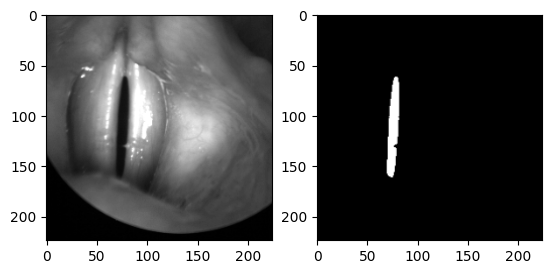

In [6]:
# Plot first training image with mask (glottal area)
def show_image_and_mask(x, y):
    plt.subplot(1,2,1)
    plt.imshow(x, cmap='gray')
    plt.subplot(1,2,2)
    plt.imshow(y, cmap='gray')
    plt.show()
    
    
show_image_and_mask(X_train[0], y_train[0])

# U-Net
U-Net is a popular encoder-decoder network that was developed for biomedical image segmentation.

**Paper:** <br>
Ronneberger, O., Fischer, P., & Brox, T. (2015, October). U-net: Convolutional networks for biomedical image segmentation. In _International Conference on Medical image computing and computer-assisted intervention_ (pp. 234-241). Springer, Cham.

<img align="left" src=https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png width=800>

In [7]:
from keras.layers import Conv2D, Input, MaxPool2D, UpSampling2D, Activation, BatchNormalization, Concatenate
from keras.models import Model


def conv_block(x, num_filters):
    x = Conv2D(filters=num_filters, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters=num_filters, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x


def build_Unet(filters=16, num_classes=1):
    # Input layer
    inputs = Input(shape=(224, 224, 1))
    
    # Encoder
    e1 = conv_block(inputs, filters)
    p1 = MaxPool2D((2, 2))(e1)
    
    e2 = conv_block(p1, filters * 2)
    p2 = MaxPool2D((2, 2))(e2)
    
    e3 = conv_block(p2, filters * 4)
    p3 = MaxPool2D((2, 2))(e3)
    
    e4 = conv_block(p3, filters * 8)
    p4 = MaxPool2D((2, 2))(e4)
    
    # Bottleneck
    b1 = conv_block(p4, filters * 16)
    
    # Decoder
    d1 = UpSampling2D()(b1)
    d1 = Concatenate()([d1, e4])
    d1 = conv_block(d1, filters * 8)
    
    d2 = UpSampling2D()(d1)
    d2 = Concatenate()([d2, e3])
    d2 = conv_block(d2, filters * 4)
    
    d3 = UpSampling2D()(d2)
    d3 = Concatenate()([d3, e2])
    d3 = conv_block(d3, filters * 2)
    
    d4 = UpSampling2D()(d3)
    d4 = Concatenate()([d4, e1])
    d4 = conv_block(d4, filters)
    
    # Output layer
    outputs = Conv2D(filters=num_classes,
                     kernel_size=1,
                     padding='same',
                     activation='sigmoid')(d4)
    
    return Model(inputs, outputs)

In [8]:
model = build_Unet(filters=16)  # original U-Net: 64 filters

In [9]:
# model.summary()

In [10]:
for layer in model.layers:
    if layer.name.startswith('conv'):
        print(layer.output_shape)  # (batch_size, height, width, channels)

(None, 224, 224, 16)
(None, 224, 224, 16)
(None, 112, 112, 32)
(None, 112, 112, 32)
(None, 56, 56, 64)
(None, 56, 56, 64)
(None, 28, 28, 128)
(None, 28, 28, 128)
(None, 14, 14, 256)
(None, 14, 14, 256)
(None, 28, 28, 128)
(None, 28, 28, 128)
(None, 56, 56, 64)
(None, 56, 56, 64)
(None, 112, 112, 32)
(None, 112, 112, 32)
(None, 224, 224, 16)
(None, 224, 224, 16)
(None, 224, 224, 1)


In [11]:
# !pip install segmentation-models

In [13]:
from segmentation_models.metrics import iou_score
from segmentation_models.losses import dice_loss
from keras.optimizers import Adam

# Compiling the model
model.compile(optimizer=Adam(learning_rate=1e-3),  # Define optimizer and learning rate
              loss=dice_loss,                      # Dice loss function
              metrics=[iou_score])     # Intersection over Union (IoU) & Dice score

## Metrics for semantic segmentation

<img align="left" src=https://upload.wikimedia.org/wikipedia/commons/thumb/1/1f/Intersection_of_sets_A_and_B.svg/1280px-Intersection_of_sets_A_and_B.svg.png width=250>

Intersection over Union: <br>
$\large IoU(A,B) = \Large\frac{|A\cap B|}{|A\cup B|} = \frac{\text{area of intersection}}{\text{area of union}}$

Dice coefficient: <br>
$\large Dice(A,B) = \Large\frac{2 |A\cap B|}{|A|+|B|}$

Examples:

<img align="left" src=https://www.baeldung.com/wp-content/uploads/sites/4/2022/04/fig2.png width="700">

Dice loss:
https://segmentation-models.readthedocs.io/en/latest/api.html#losses
https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=7785132

In [ ]:
history = model.fit(X_train, y_train,
                    batch_size=64,
                    epochs=50)

In [36]:
# model.save('unet.h5')
# pd.DataFrame(history.history).to_csv('history.csv')

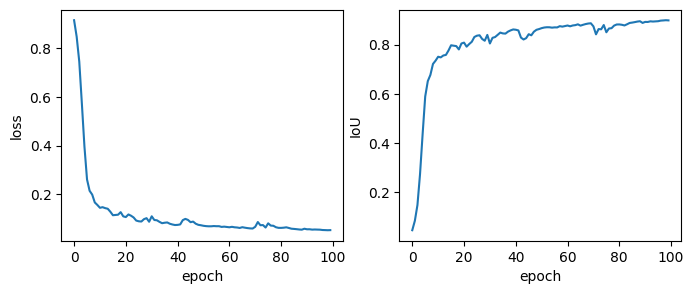

In [20]:
# Usually, you you would access the training history like this:
# hist = history.history

# But I trained the model beforehand, and we load the history from a .csv file:
hist = pd.read_csv('history.csv')

# Plot loss for each epoch
plt.figure(figsize=(8,3))
plt.subplot(1, 2, 1)
plt.plot(hist['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')

# Plot IoU score for each epoch
plt.subplot(1, 2, 2)
plt.plot(hist['iou_score'])
plt.xlabel('epoch')
plt.ylabel('IoU')
plt.show()

# # Plot accuracy
# plt.subplot(1, 2, 2)
# plt.plot(hist['accuracy'])
# plt.xlabel('epoch')
# plt.ylabel('accuracy')
# plt.show()

In [21]:
from keras.models import load_model

loaded_model = load_model('unet.h5',
                          custom_objects={'iou_score': iou_score,
                                          'dice_loss': dice_loss})

In [25]:
# How good does the model perform on data it has not seen before = the test dataset?
scores = loaded_model.evaluate(X_test, y_test)

32/32 [==============================] - 32s 987ms/step - loss: 0.0738 - accuracy: 0.9964 - iou_score: 0.8628


In [26]:
# Get predicted masks for all test images
predictions = loaded_model.predict(X_test)

32/32 [==============================] - 31s 965ms/step


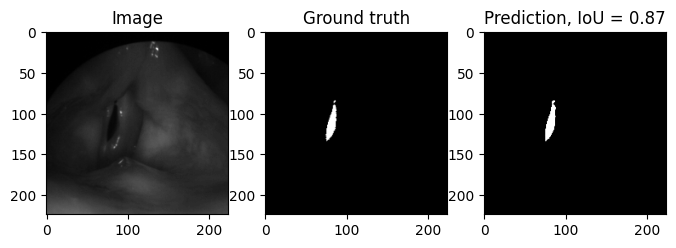

In [27]:
idx = 0

img = X_test[idx]
mask = y_test[idx]
pred = predictions[idx]

# IoU score
iou = iou_score(mask, pred)

# Plot image, ground truth and prediction
plt.figure(figsize=(8,3))
plt.subplot(1,3,1)
plt.title('Image')
plt.imshow(img, cmap='gray')

plt.subplot(1,3,2)
plt.title('Ground truth')
plt.imshow(mask, cmap='gray')

plt.subplot(1,3,3)
plt.title('Prediction, IoU = {:.2f}'.format(iou))
plt.imshow(pred, cmap='gray')
plt.show()

In [28]:
# Data augmentation

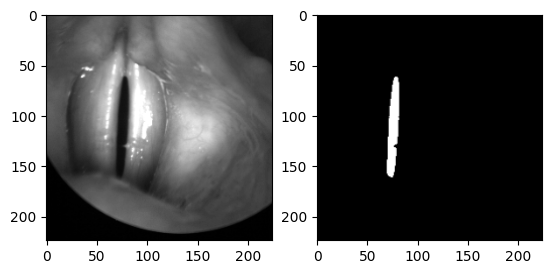

In [29]:
train_image = X_train[0]
train_mask = y_train[0]

show_image_and_mask(train_image, train_mask)

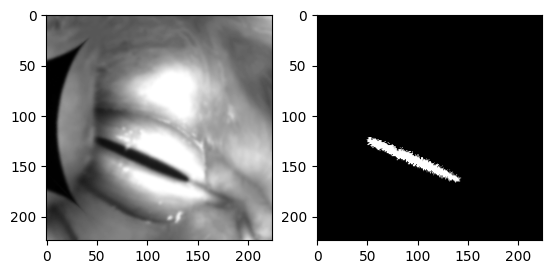

In [40]:
import albumentations as A

aug = A.Rotate(p=1)
# aug = A.HorizontalFlip(p=1)

augmented = aug(image=train_image, mask=train_mask)

train_image = augmented['image']
train_mask = augmented['mask']

show_image_and_mask(train_image, train_mask)